# Load data

https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

https://www.kaggle.com/code/roshaaann30/customer-churn-prediction-analytics

In [1]:
import pandas as pd

df = pd.read_csv('../../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df['SeniorCitizen'].unique()

array([0, 1])

In [4]:
df['Partner'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [5]:
df['Dependents'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [6]:
df['PhoneService'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [7]:
df['MultipleLines'].unique()

<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [8]:
df['InternetService'].unique()

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [9]:
df['Contract'].unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [10]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

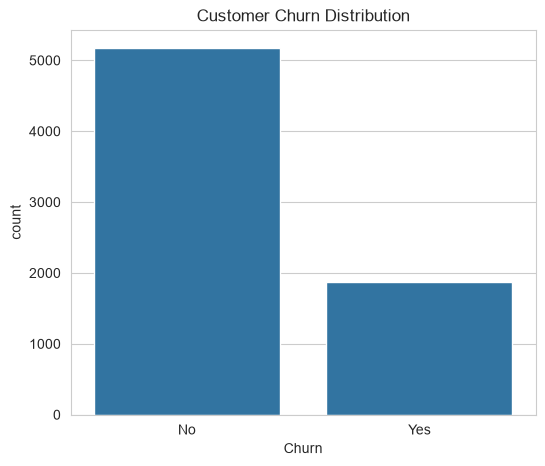

In [12]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

# Data Cleaning & Preprocessing

In [13]:
# ============================================
# CHECK MISSING VALUES
# ============================================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
# ============================================
# MISSING VALUE PERCENTAGE
# ============================================

missing_percent = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percent
}).sort_values(
    'Missing Percentage',
    ascending=False
)

,Missing Values,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [15]:
# ============================================
# CHECK DATA TYPES
# ============================================

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [16]:
# ============================================
# CONVERT TOTALCHARGES
# ============================================

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [17]:
# ============================================
# CHECK NEW MISSING VALUES
# ============================================

df['TotalCharges'].isnull().sum()

np.int64(11)

In [18]:
df['TotalCharges'] = (
    df['TotalCharges']
    .fillna(
        df['TotalCharges']
        .median()
    )
)

df.isnull().sum().sum()

np.int64(0)

In [19]:
# ============================================
# CHECK DUPLICATES
# ============================================

df.duplicated().sum()

np.int64(0)

In [20]:
# ============================================
# REMOVE DUPLICATES
# ============================================

df.drop_duplicates(
    inplace=True
)

print(
    "New Shape:",
    df.shape
)

New Shape: (7043, 21)


In [21]:
# The customerID column uniquely identifies each customer.
# It does not contribute predictive information and will be removed before modeling.

df.drop(
    'customerID',
    axis=1,
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# ============================================
# CHURN ENCODING
# ============================================

df['Churn'] = (
    df['Churn']
    .map({
        'No': 0,
        'Yes': 1
    })
)

df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [23]:
import numpy as np

# ============================================
# NUMERICAL FEATURES
# ============================================

numerical_cols = (
    df
    .select_dtypes(
        include=np.number
    )
    .columns
)

numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='str')

In [24]:
# ============================================
# CATEGORICAL FEATURES
# ============================================

categorical_cols = (
    df
    .select_dtypes(
        exclude=np.number
    )
    .columns
)

categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

# Exploratory Data Analysis (EDA)

The objective is to identify patterns that explain why customers leave.

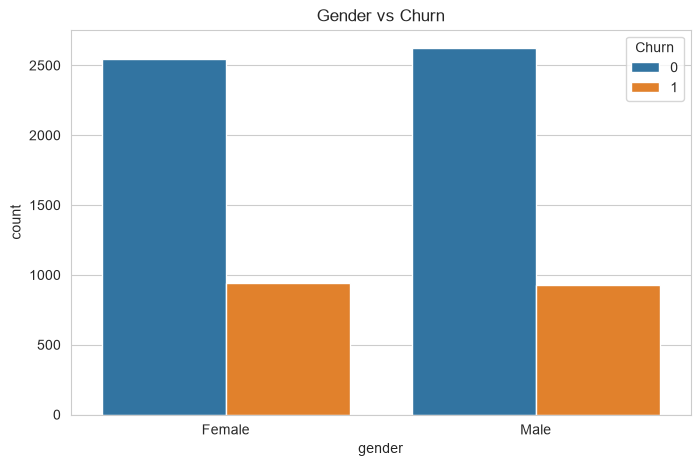

In [25]:
# ============================================
# GENDER VS CHURN
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='gender',
    hue='Churn'
)

plt.title(
    'Gender vs Churn'
)

plt.show()

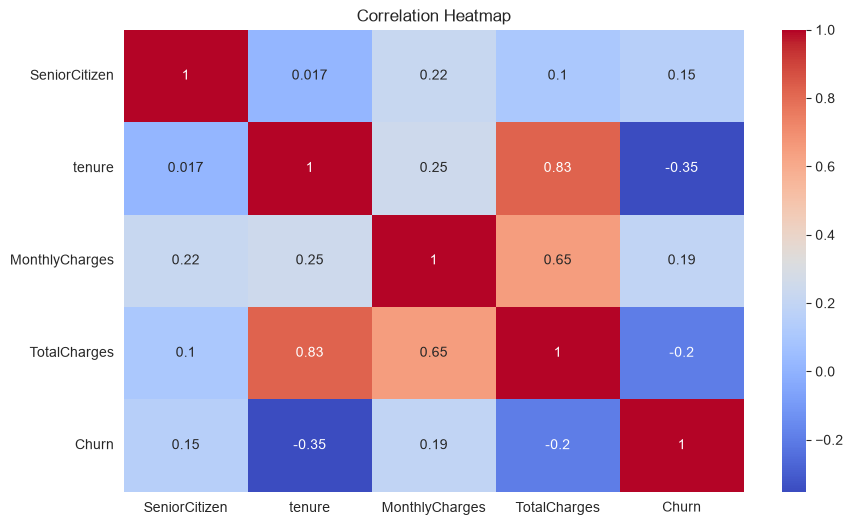

In [26]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

# Feature Engineering

Feature engineering transforms raw customer information into more meaningful variables.

The goal is to create features that better represent customer behavior and improve predictive performance.

In [27]:
# ============================================
# TENURE GROUPS
# ============================================

def tenure_group(tenure):

    if tenure <= 12:
        return '0-1 Year'

    elif tenure <= 24:
        return '1-2 Years'

    elif tenure <= 48:
        return '2-4 Years'

    elif tenure <= 60:
        return '4-5 Years'

    else:
        return '5+ Years'


df['TenureGroup'] = (
    df['tenure']
    .apply(tenure_group)
)

df['TenureGroup'].value_counts()

TenureGroup
0-1 Year     2186
2-4 Years    1594
5+ Years     1407
1-2 Years    1024
4-5 Years     832
Name: count, dtype: int64

In [28]:
# ============================================
# AVERAGE MONTHLY SPEND
# ============================================

df['AvgMonthlySpend'] = (
    df['TotalCharges']
    /
    (df['tenure'] + 1)
)

df['AvgMonthlySpend'].head()

0    14.925000
1    53.985714
2    36.050000
3    40.016304
4    50.550000
Name: AvgMonthlySpend, dtype: float64

In [29]:
# ============================================
# CUSTOMER LIFETIME VALUE
# ============================================

df['CLV'] = (
    df['MonthlyCharges']
    *
    df['tenure']
)

df['CLV'].head()

0      29.85
1    1936.30
2     107.70
3    1903.50
4     141.40
Name: CLV, dtype: float64

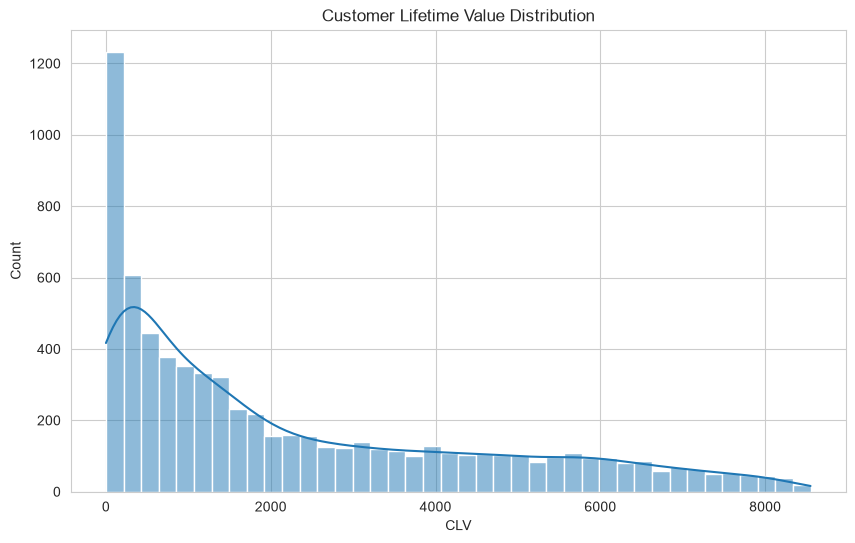

In [30]:
# ============================================
# CLV DISTRIBUTION
# ============================================

# Customer Lifetime Value (CLV) estimates the total revenue generated by a customer throughout their relationship with the company.
# High-value customers are often priority targets for retention programs.

plt.figure(figsize=(10,6))

sns.histplot(
    df['CLV'],
    bins=40,
    kde=True
)

plt.title(
    'Customer Lifetime Value Distribution'
)

plt.show()

In [31]:
# ============================================
# ONE-HOT ENCODING
# ============================================

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(
    "Encoded Shape:",
    df_encoded.shape
)

Encoded Shape: (7043, 37)


In [32]:
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,CLV,gender_Male,Partner_Yes,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_4-5 Years,TenureGroup_5+ Years
0,0,1,29.85,29.85,0,14.925000,29.85,False,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,0,53.985714,1936.30,True,False,False,...,True,False,False,False,False,True,False,True,False,False
2,0,2,53.85,108.15,1,36.050000,107.70,True,False,False,...,False,False,True,False,False,True,False,False,False,False
3,0,45,42.30,1840.75,0,40.016304,1903.50,True,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,1,50.550000,141.40,False,False,False,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,79.620000,2035.20,True,True,True,...,True,False,True,False,False,True,True,False,False,False
7039,0,72,103.20,7362.90,0,100.861644,7430.40,False,True,True,...,True,False,True,True,False,False,False,False,False,True
7040,0,11,29.60,346.45,0,28.870833,325.60,False,True,True,...,False,False,True,False,True,False,False,False,False,False
7041,1,4,74.40,306.60,1,61.320000,297.60,True,True,False,...,False,False,True,False,False,True,False,False,False,False


In [33]:
# ============================================
# FEATURES & TARGET
# ============================================

X = df_encoded.drop(
    'Churn',
    axis=1
)

y = df_encoded['Churn']

print(
    "Features Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Features Shape: (7043, 36)
Target Shape: (7043,)


In [34]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(
    "Training Shape:",
    X_train.shape
)

print(
    "Testing Shape:",
    X_test.shape
)

Training Shape: (5634, 36)
Testing Shape: (1409, 36)


In [35]:
# ============================================
# FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Scaling Completed"
)

Scaling Completed


# Machine Learning Models

Three classification models will be developed and compared:

- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

Model performance will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best-performing model will be selected for feature importance analysis and business recommendations.

In [36]:
# ============================================
# IMPORT MODELS
# ============================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Models Imported Successfully")

Models Imported Successfully


In [37]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

print("Logistic Regression Trained")

Logistic Regression Trained


In [38]:
# ============================================
# LOGISTIC REGRESSION METRICS
# ============================================

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))
print("ROC AUC  :", round(lr_auc,4))

Accuracy : 0.8041
Precision: 0.6644
Recall   : 0.5294
F1 Score : 0.5893
ROC AUC  : 0.8458


In [39]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

print("Random Forest Trained")

Random Forest Trained


In [40]:
# ============================================
# RANDOM FOREST METRICS
# ============================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))
print("ROC AUC  :", round(rf_auc,4))

Accuracy : 0.7935
Precision: 0.6416
Recall   : 0.5027
F1 Score : 0.5637
ROC AUC  : 0.8251


In [41]:
# ============================================
# XGBOOST CLASSIFIER
# ============================================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

print("XGBoost Trained")

XGBoost Trained


In [42]:
# ============================================
# XGBOOST METRICS
# ============================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision:", round(xgb_precision,4))
print("Recall   :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))
print("ROC AUC  :", round(xgb_auc,4))

Accuracy : 0.8027
Precision: 0.6622
Recall   : 0.5241
F1 Score : 0.5851
ROC AUC  : 0.8422


In [43]:
# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    'Precision':[
        lr_precision,
        rf_precision,
        xgb_precision
    ],

    'Recall':[
        lr_recall,
        rf_recall,
        xgb_recall
    ],

    'F1 Score':[
        lr_f1,
        rf_f1,
        xgb_f1
    ],

    'ROC-AUC':[
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.664430,0.529412,0.589286,0.845845
1,Random Forest,0.793471,0.641638,0.502674,0.563718,0.825118
2,XGBoost,0.802697,0.662162,0.524064,0.585075,0.842178


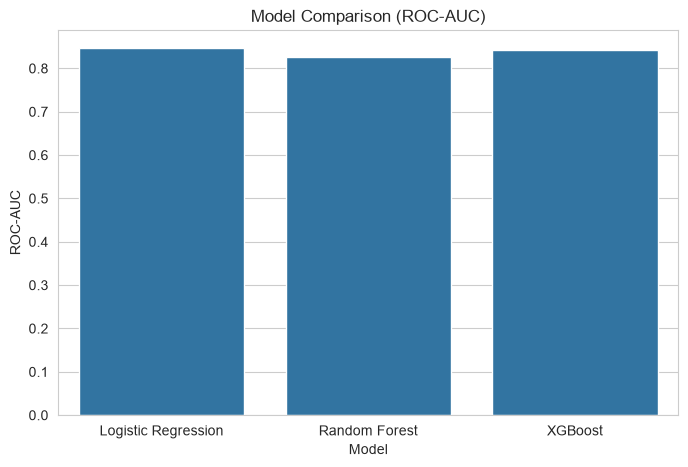

In [44]:
# ============================================
# MODEL PERFORMANCE
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='ROC-AUC'
)

plt.title(
    'Model Comparison (ROC-AUC)'
)

plt.show()

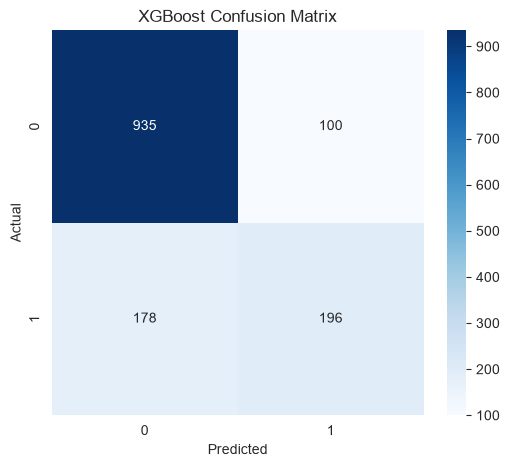

In [45]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'XGBoost Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

In [46]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# Feature Importance Analysis

Predicting churn is only part of the solution.

Businesses also need to understand:

- Why customers leave
- Which factors drive churn
- Which customers should be prioritized

Feature importance helps transform machine learning predictions into actionable business insights.

In [47]:
# ============================================
# XGBOOST FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        xgb_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
12,InternetService_Fiber optic,0.272239
27,Contract_Two year,0.192992
26,Contract_One year,0.140998
13,InternetService_No,0.066452
30,PaymentMethod_Electronic check,0.036624
25,StreamingMovies_Yes,0.035826
1,tenure,0.035381
15,OnlineSecurity_Yes,0.020236
28,PaperlessBilling_Yes,0.019724
11,MultipleLines_Yes,0.016451


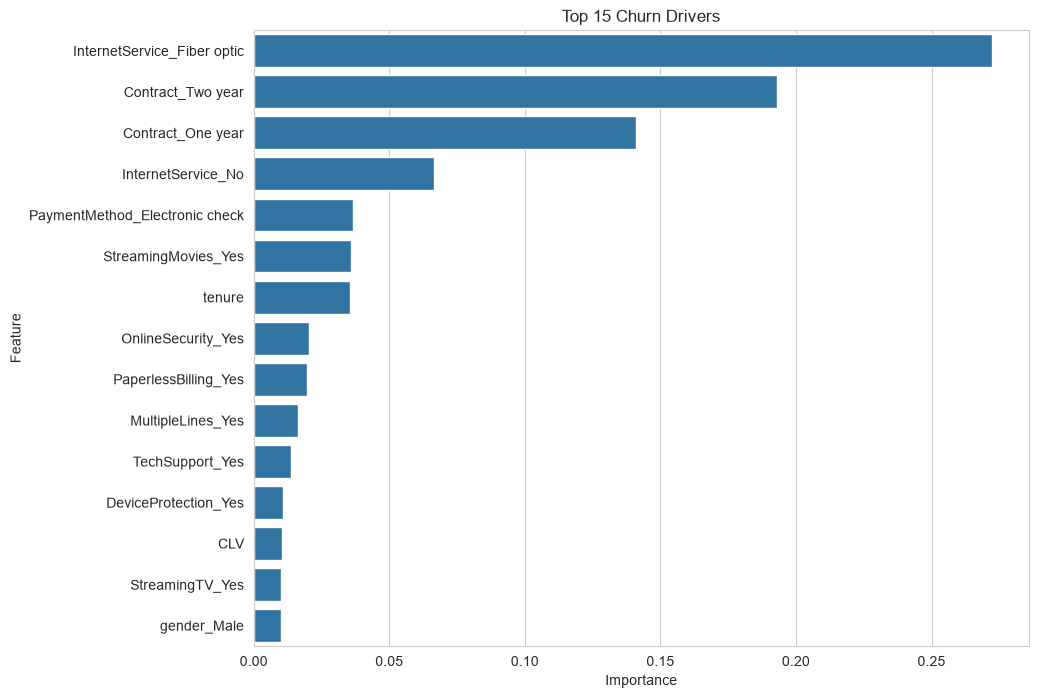

In [48]:
# ============================================
# TOP 15 FEATURES
# ============================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Churn Drivers'
)

plt.show()

In [49]:
# ============================================
# CHURN RISK PROBABILITY
# ============================================

risk_df = pd.DataFrame({

    'Actual_Churn':
        y_test,

    'Churn_Probability':
        xgb_prob

})

risk_df.head()

,Actual_Churn,Churn_Probability
437,0,0.011859
2280,0,0.864271
2235,0,0.068268
4460,0,0.255587
3761,0,0.003992


In [50]:
# ============================================
# HIGH RISK CUSTOMERS
# ============================================

# Customers with high predicted churn probability should be prioritized for retention efforts.

high_risk = risk_df[
    risk_df['Churn_Probability']
    > 0.80
]

print(
    "High Risk Customers:",
    len(high_risk)
)

High Risk Customers: 63


In [51]:
# ============================================
# CUSTOMER VALUE AT RISK
# ============================================

at_risk_revenue = (
    df.loc[
        high_risk.index,
        'MonthlyCharges'
    ].sum()
)

print(
    "Monthly Revenue At Risk:",
    round(
        at_risk_revenue,
        2
    )
)

Monthly Revenue At Risk: 5357.6


In [52]:
# ============================================
# PROJECT DASHBOARD
# ============================================

best_auc = max(
    lr_auc,
    rf_auc,
    xgb_auc
)

dashboard = pd.DataFrame({

    'Metric': [

        'Dataset Size',
        'Features',
        'Best Model',
        'Best ROC-AUC',
        'High Risk Customers'

    ],

    'Value': [

        len(df),

        X.shape[1],

        'XGBoost',

        round(best_auc,4),

        len(high_risk)

    ]

})

dashboard

,Metric,Value
0,Dataset Size,7043
1,Features,36
2,Best Model,XGBoost
3,Best ROC-AUC,0.8458
4,High Risk Customers,63


# Business Recommendations

Based on the analysis, the following recommendations are proposed.

1. Customer Retention
- Prioritize customers with high churn probability.
- Offer targeted retention incentives.
- Improve onboarding for new customers.

2. Contract Strategy
- Encourage long-term contract adoption.
- Provide benefits for contract renewals.

3. Revenue Protection
- Focus on retaining high-value customers.
- Monitor customer lifetime value continuously.

4. Service Improvement
- Improve customer experience for vulnerable segments.
- Enhance support quality and responsiveness.
